## 0. Preparation

In [45]:
%pip install lightning ray lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3ca0fbdb2b736a6c817a576ed09297ac39c4936c2bab75aaf62c4943853c4396
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [7]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader, TensorDataset
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import accuracy_score
import numpy as np
from ray import tune
from ray.tune.integration.pytorch_lightning import TuneReportCallback

## 3. Classifier implementation with PyTorch Lightning

In [5]:
class RobotDataModule(pl.LightningDataModule):
    def __init__(self, X_train, X_test, y_train, y_test, batch_size=64):
        super().__init__()
        self.X_train = torch.tensor(X_train, dtype=torch.float32)
        self.X_test  = torch.tensor(X_test,  dtype=torch.float32)
        self.y_train = torch.tensor(y_train, dtype=torch.long)
        self.y_test  = torch.tensor(y_test,  dtype=torch.long)
        self.batch_size = batch_size

    def setup(self, stage=None):
        from torch.utils.data import random_split
        full = TensorDataset(self.X_train, self.y_train)
        val_size = int(0.2 * len(full))
        train_size = len(full) - val_size
        self.train_ds, self.val_ds = random_split(full, [train_size, val_size])
        self.test_ds = TensorDataset(self.X_test, self.y_test)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)
    def val_dataloader(self):
        return DataLoader(self.val_ds,   batch_size=self.batch_size)
    def test_dataloader(self):
        return DataLoader(self.test_ds,  batch_size=self.batch_size)

In [6]:
class LitClassifier(pl.LightningModule):
    def __init__(self, input_size, hidden_size, num_classes, lr=1e-3, dropout=0.3):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, _):
        x, y = batch
        loss = self.criterion(self(x), y)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = accuracy_score(y.cpu(), logits.argmax(1).cpu())
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc',  acc,  prog_bar=True)

    def test_step(self, batch, _):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = accuracy_score(y.cpu(), logits.argmax(1).cpu())
        self.log('test_loss', loss)
        self.log('test_acc',  acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

In [17]:
X_train_scaled.shape

(1, 4364)

In [26]:
X_train_scaled  = np.load('X_train_scaled.npy')
X_test_scaled   = np.load('X_test_scaled.npy')
y_train_encoded = np.load('y_train_encoded.npy')
y_test_encoded  = np.load('y_test_encoded.npy')

print(X_train_scaled.shape)
print(y_train_encoded.shape)

INPUT_SIZE  = X_train_scaled.shape[1]
NUM_CLASSES = len(np.unique(y_train_encoded))

(4364, 12)
(4364,)
Input size: 12, Klasy: 4


In [27]:
datamodule = RobotDataModule(X_train_scaled, X_test_scaled, y_train_encoded, y_test_encoded)
model      = LitClassifier(input_size=INPUT_SIZE, hidden_size=128, num_classes=NUM_CLASSES)

early_stop = EarlyStopping(monitor='val_loss', patience=5, mode='min')
checkpoint = ModelCheckpoint(monitor='val_loss', mode='min', save_top_k=1, filename='best')

trainer = Trainer(
    max_epochs=50,
    accelerator='gpu', devices=1,
    callbacks=[early_stop, checkpoint]
)
trainer.fit(model, datamodule=datamodule)
trainer.test(model, datamodule=datamodule)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net       │ Sequential       │ 18.7 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 18.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 18.7 K                                                                                               
Total estimated model params size (MB): 0.075                                                                      
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9001831412315369     │
│         test_loss         │    0.24887579679489136    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.24887579679489136, 'test_acc': 0.9001831412315369}]

In [33]:
import logging
import os
import warnings
import ray
from ray import tune
from ray.tune import CLIReporter
from ray.tune.integration.pytorch_lightning import (
    TuneReportCheckpointCallback,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

ray.shutdown()
ray.init(num_cpus=2, num_gpus=1, ignore_reinit_error=True)

os.environ["TUNE_DISABLE_AUTO_CALLBACK_LOGGERS"] = "1"
logging.getLogger("ray").setLevel(logging.ERROR)
logging.getLogger("ray.tune").setLevel(logging.ERROR)


def train_tune(config):
    model = LitClassifier(
        input_size=INPUT_SIZE,
        hidden_size=config["hidden_size"],
        num_classes=NUM_CLASSES,
        lr=config["lr"],
        dropout=config["dropout"],
    )

    tune_callback = TuneReportCheckpointCallback(
        metrics={"loss": "val_loss", "acc": "val_acc"}, on="validation_end"
    )

    trainer = Trainer(
        max_epochs=30,
        accelerator="gpu",
        devices=1,
        callbacks=[tune_callback],
        enable_progress_bar=False,
    )
    trainer.fit(model, datamodule=datamodule)


reporter = CLIReporter(
    metric_columns=["loss", "acc"],
    parameter_columns=["hidden_size", "lr", "dropout"],
    max_progress_rows=15,
)

analysis = tune.run(
    tune.with_resources(train_tune, resources={"cpu": 1, "gpu": 1}),
    config={
        "hidden_size": tune.choice([64, 128, 256]),
        "lr": tune.loguniform(1e-4, 1e-2),
        "dropout": tune.choice([0.2, 0.3, 0.5]),
    },
    num_samples=15,
    metric="loss",
    mode="min",
    progress_reporter=reporter,
    verbose=1,
)

best_config = analysis.get_best_config(metric="loss", mode="min")
print("Best config:", best_config)

2026-06-22 22:19:59,613	INFO worker.py:2012 -- Started a local Ray instance.


+-------------------------------------------------------------------+
| Configuration for experiment     train_tune_2026-06-22_22-20-03   |
+-------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator            |
| Scheduler                        FIFOScheduler                    |
| Number of trials                 15                               |
+-------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_tune_2026-06-22_22-20-03

Trial status: 15 PENDING
Current time: 2026-06-22 22:20:03. Total running time: 0s
Logical resource usage: 1.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
+-----------------------------------------------------------------------------+
| Trial name               status       hidden_size            lr     dropout |
+-----------------------------------------------------------------------------+
| train_tune_83c21_00000   PEND

(pid=14669) /usr/local/lib/python3.12/dist-packages/ray/_private/function_manager.py:677: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(pid=14669)   actor_class = pickle.loads(pickled_class)



Trial train_tune_83c21_00000 started with configuration:
+-------------------------------------------------+
| Trial train_tune_83c21_00000 config             |
+-------------------------------------------------+
| dropout                                     0.5 |
| hidden_size                                 256 |
| lr                                      0.00016 |
+-------------------------------------------------+


(train_tune pid=14669) GPU available: True (cuda), used: True
(train_tune pid=14669) TPU available: False, using: 0 TPU cores
(train_tune pid=14669) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(train_tune pid=14669) 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


...

(train_tune pid=17096) GPU available: True (cuda), used: True
(train_tune pid=17096) TPU available: False, using: 0 TPU cores
(train_tune pid=17096) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(train_tune pid=17096) 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


(train_tune pid=17096) ┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
(train_tune pid=17096) ┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
(train_tune pid=17096) ┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
(train_tune pid=17096) │ 0 │ net       │ Sequential       │ 70.1 K │ train │     0 │
(train_tune pid=17096) │ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
(train_tune pid=17096) └───┴───────────┴──────────────────┴────────┴───────┴───────┘
(train_tune pid=17096) Trainable params: 70.1 K                                                        
(train_tune pid=17096) Non-trainable params: 0                                                         
(train_tune pid=17096) Total params: 70.1 K                                                            
(train_tune pid=17096) Total estimated model params size (MB): 0.281                                   
(train_tune pid=17096) Modules in train mode: 9                           

(train_tune pid=17096) LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
(train_tune pid=17096) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(train_tune pid=17096) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(train_tune pid=17096) `weights_only` was not set, defaulting to `False`.
(train_tune pid=17096) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_tune_2026-06-22_22-20-03/train_tune_83c21_00014_14_dropout=0.3000,hidden_size=256,lr=0.0071_2026-06-22_22-20-03/checkpoint_000000)
(train_tune pid=17096) `weights_only` was not set, defaulting to `False`.
(train_tune pid=17096) Checkpoint successfully created at: Checkpoint(filesystem=local, path=


Trial train_tune_83c21_00014 completed after 30 iterations at 2026-06-22 22:27:53. Total running time: 7min 50s
+-----------------------------------------------------------+
| Trial train_tune_83c21_00014 result                       |
+-----------------------------------------------------------+
| checkpoint_dir_name                     checkpoint_000029 |
| time_this_iter_s                                    0.313 |
| time_total_s                                     14.24234 |
| training_iteration                                     30 |
| acc                                                0.9094 |
| loss                                              0.23998 |
+-----------------------------------------------------------+

Trial status: 15 TERMINATED
Current time: 2026-06-22 22:27:53. Total running time: 7min 50s
Logical resource usage: 1.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Current best trial: 83c21_00014 with loss=0.2399778664112091 and params={'hidden_size': 256, 'lr'

(train_tune pid=17096) `weights_only` was not set, defaulting to `False`.
(train_tune pid=17096) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_tune_2026-06-22_22-20-03/train_tune_83c21_00014_14_dropout=0.3000,hidden_size=256,lr=0.0071_2026-06-22_22-20-03/checkpoint_000029)
(train_tune pid=17096) `Trainer.fit` stopped: `max_epochs=30` reached.


In [ ]:
best_model = LitClassifier(
    input_size=INPUT_SIZE,
    hidden_size=best_config['hidden_size'],
    num_classes=NUM_CLASSES,
    lr=best_config['lr'],
    dropout=best_config['dropout']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')
checkpoint = ModelCheckpoint(monitor='val_loss', mode='min', save_top_k=1, filename='best_final')

trainer = Trainer(
    max_epochs=100,
    accelerator='gpu', devices=1,
    callbacks=[early_stop, checkpoint]
)
trainer.fit(best_model, datamodule=datamodule)
trainer.test(best_model, datamodule=datamodule)
torch.save(best_model.state_dict(), 'best_model.pt')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net       │ Sequential       │ 70.1 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 70.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 70.1 K                                                                                               
Total estimated model params size (MB): 0.281                                                                      
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9276556968688965     │
│         test_loss         │    0.1764172613620758     │
└───────────────────────────┴───────────────────────────┘

## 4. Calibration (Temperature)
- T > 1  (overconfident)
- T < 1 (not confident)

In [37]:
from torch.nn.functional import softmax

best_model.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for x, y in datamodule.val_dataloader():
        all_logits.append(best_model(x.to(best_model.device)))
        all_labels.append(y)

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

class TemperatureScaling(nn.Module):
    def __init__(self):
        super().__init__()
        self.T = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.T

temp_model = TemperatureScaling()
optimizer  = torch.optim.LBFGS([temp_model.T], lr=0.01, max_iter=100)
criterion  = nn.CrossEntropyLoss()

def eval_step():
    optimizer.zero_grad()
    loss = criterion(temp_model(all_logits), all_labels)
    loss.backward()
    return loss

optimizer.step(eval_step)
print(f"T = {temp_model.T.item():.4f}")

T = 0.9741


In [39]:
best_model.eval()
all_logits_test, all_labels_test = [], []

with torch.no_grad():
    for x, y in datamodule.test_dataloader():
        all_logits_test.append(best_model(x.to(best_model.device)))
        all_labels_test.append(y)

logits_test = torch.cat(all_logits_test).cpu()
y_test_true = torch.cat(all_labels_test).cpu().numpy()

probs_raw  = softmax(logits_test, dim=1).numpy()
probs_cal  = softmax(temp_model(logits_test), dim=1).detach().numpy()

confidence = probs_cal.max(axis=1)
preds      = probs_cal.argmax(axis=1)

print(f"Average before: {probs_raw.max(axis=1).mean():.4f}")
print(f"Average after:   {confidence.mean():.4f}")

Average before: 0.9390
Average after:   0.9406


## 5. Most confident and least confident

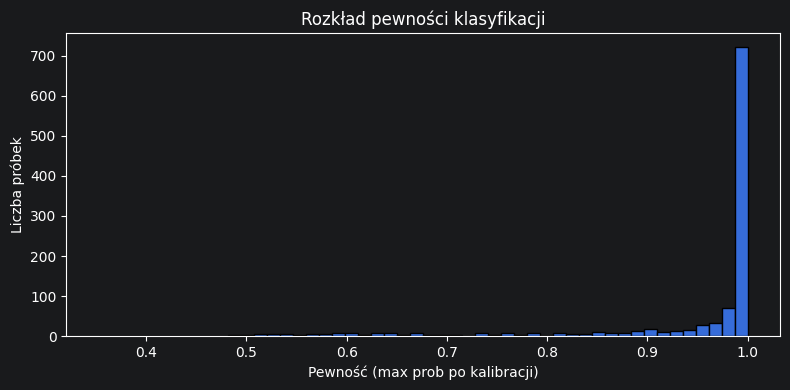

Most Confident   (>=0.9): 903
Not confident (<0.5): 7


In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(confidence, bins=50, edgecolor='k')
plt.xlabel('Pewność (max prob po kalibracji)')
plt.ylabel('Liczba próbek')
plt.title('Rozkład pewności klasyfikacji')
plt.tight_layout()
plt.show()

CERTAIN_THRESH   = 0.90
UNCERTAIN_THRESH = 0.50

certain_idx   = np.where(confidence >= CERTAIN_THRESH)[0]
uncertain_idx = np.where(confidence <  UNCERTAIN_THRESH)[0]

print(f"Most Confident   (>={CERTAIN_THRESH}): {len(certain_idx)}")
print(f"Not confident (<{UNCERTAIN_THRESH}): {len(uncertain_idx)}")

X_certain   = X_test_scaled[certain_idx]
X_uncertain = X_test_scaled[uncertain_idx]
y_certain   = y_test_true[certain_idx]
y_uncertain = y_test_true[uncertain_idx]

## 6. Permutatnion feature importance

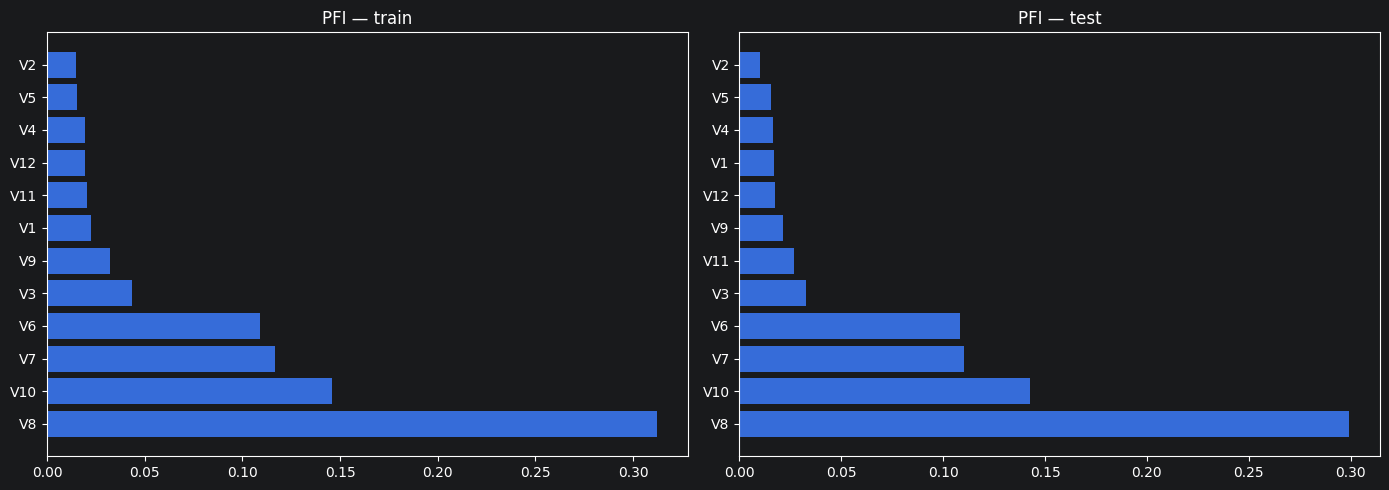


TRAIN — important: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12']

TEST — important: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12']


In [43]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

class TorchWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.classes_ = np.arange(NUM_CLASSES)

    def fit(self, X, y): return self

    def predict(self, X):
        t = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            return self.model(t).argmax(1).numpy()

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

clf = TorchWrapper(best_model.cpu())

pfi_train = permutation_importance(clf, X_train_scaled, y_train_encoded, n_repeats=30, random_state=42)
pfi_test  = permutation_importance(clf, X_test_scaled,  y_test_encoded,  n_repeats=30, random_state=42)

feature_names = ["V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9", "V10", "V11", "V12"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pfi, title in zip(axes, [pfi_train, pfi_test],  ['PFI — train', 'PFI — test']):
    sorted_idx = pfi.importances_mean.argsort()[::-1]
    ax.barh([feature_names[i] for i in sorted_idx], pfi.importances_mean[sorted_idx])
    ax.set_title(title)
plt.tight_layout()
plt.show()

for name, pfi, label in [('TRAIN', pfi_train, y_train_encoded), ('TEST', pfi_test, y_test_encoded)]:
    significant = [feature_names[i] for i in range(len(feature_names))
                   if (pfi.importances_mean[i] - 2*pfi.importances_std[i]) > 0]
    print(f"\n{name} — important: {significant}")

## Lime global vs PFI

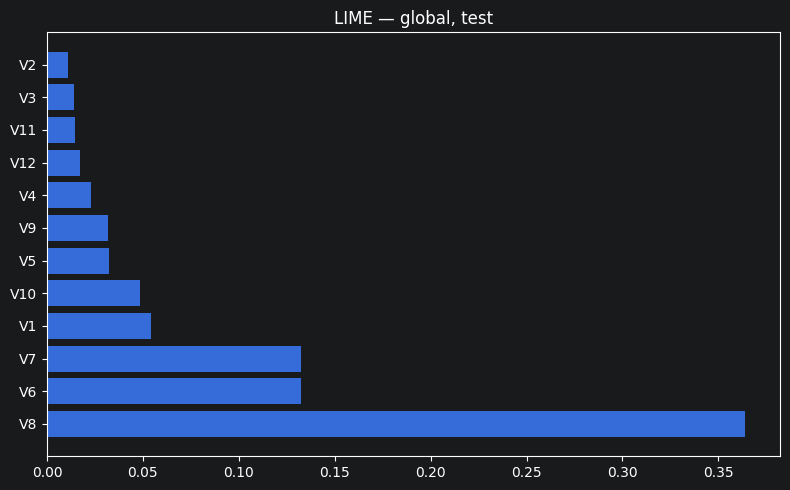


PFI vs LIME:
PFI  ranking: ['V8', 'V10', 'V7', 'V6', 'V3', 'V11', 'V9', 'V12', 'V1', 'V4', 'V5', 'V2']
LIME ranking: ['V8', 'V6', 'V7', 'V1', 'V10', 'V5', 'V9', 'V4', 'V12', 'V11', 'V3', 'V2']


In [47]:
import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=feature_names,
    class_names=[str(c) for c in ["1", "2", "3", "4"]],
    mode='classification'
)

def predict_proba(X):
    t = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        return softmax(best_model(t), dim=1).numpy()

lime_weights = np.zeros((len(X_test_scaled), len(feature_names)))

for i in range(len(X_test_scaled)):
    exp = explainer.explain_instance(X_test_scaled[i], predict_proba, num_features=len(feature_names))
    w = dict(exp.as_list())
    for j, fname in enumerate(feature_names):
        for key, val in w.items():
            if fname in key:
                lime_weights[i, j] = val
                break

global_lime = np.abs(lime_weights).mean(axis=0)
sorted_idx  = global_lime.argsort()[::-1]

plt.figure(figsize=(8, 5))
plt.barh([feature_names[i] for i in sorted_idx], global_lime[sorted_idx])
plt.title('LIME — global, test')
plt.tight_layout()
plt.show()

# Porównanie LIME vs PFI
print("\nPFI vs LIME:")
pfi_ranking  = pfi_test.importances_mean.argsort()[::-1]
lime_ranking = global_lime.argsort()[::-1]
print(f"PFI  ranking: {[feature_names[i] for i in pfi_ranking]}")
print(f"LIME ranking: {[feature_names[i] for i in lime_ranking]}")

## 8. Lime locally

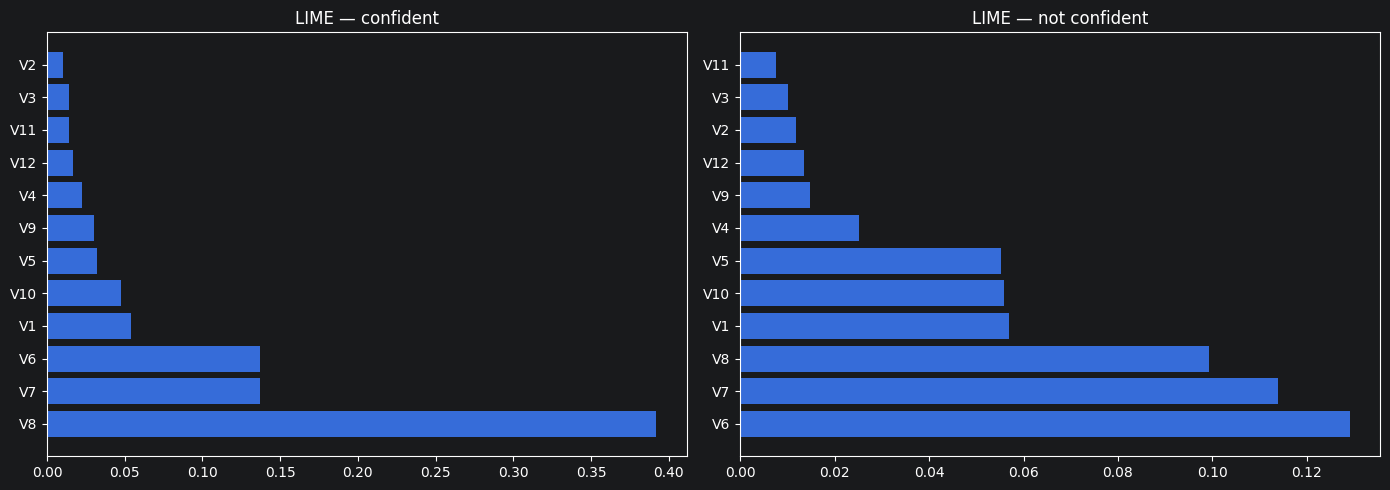


Confident:    ['V8', 'V7', 'V6', 'V1', 'V10', 'V5', 'V9', 'V4', 'V12', 'V11', 'V3', 'V2']
Not confident: ['V6', 'V7', 'V8', 'V1', 'V10', 'V5', 'V4', 'V9', 'V12', 'V2', 'V3', 'V11']


In [48]:
def lime_mean_weights(X_subset):
    weights = np.zeros((len(X_subset), len(feature_names)))
    for i in range(len(X_subset)):
        exp = explainer.explain_instance(X_subset[i], predict_proba, num_features=len(feature_names))
        w = dict(exp.as_list())
        for j, fname in enumerate(feature_names):
            for key, val in w.items():
                if fname in key:
                    weights[i, j] = val
                    break
    return np.abs(weights).mean(axis=0)

lime_certain   = lime_mean_weights(X_certain)
lime_uncertain = lime_mean_weights(X_uncertain)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, weights, title in zip(axes, [lime_certain, lime_uncertain], ['LIME — confident', 'LIME — not confident']):
    sorted_idx = weights.argsort()[::-1]
    ax.barh([feature_names[i] for i in sorted_idx], weights[sorted_idx])
    ax.set_title(title)
plt.tight_layout()
plt.show()

print("\nConfident:   ", [feature_names[i] for i in lime_certain.argsort()[::-1]])
print("Not confident:", [feature_names[i] for i in lime_uncertain.argsort()[::-1]])